# Unit 2 | NLP 02 — Vectorization: CountVec & TF-IDF

Machine learning models need numbers. This notebook converts preprocessed text into numeric feature matrices using two classical approaches:

1. **CountVectorizer** — term frequency (bag of words)
2. **TF-IDF** — term frequency × inverse document frequency

We'll explore hyperparameters, visualize the feature space, and compare the two representations on the same documents.

**Dataset:** sklearn 20 Newsgroups

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
plt.style.use('dark_background')

In [2]:
# ── CONFIGURATION ────────────────────────────────────────────────────────────
CATEGORIES   = ['sci.space', 'comp.graphics', 'rec.sport.hockey', 'talk.religion.misc']
RANDOM_STATE = 42
# ─────────────────────────────────────────────────────────────────────────────

In [3]:
data = fetch_20newsgroups(
    subset='train',
    categories=CATEGORIES,
    remove=('headers', 'footers', 'quotes'),
    random_state=RANDOM_STATE
)

print(f"Training documents: {len(data.data):,}")
print(f"Categories: {data.target_names}")

Training documents: 2,154
Categories: ['comp.graphics', 'rec.sport.hockey', 'sci.space', 'talk.religion.misc']


## The Term-Document Matrix

The central idea of classical NLP feature extraction is the **term-document matrix**:

- Rows = documents
- Columns = vocabulary terms
- Cell (i, j) = some measure of how important term j is in document i

```
            space  rocket  hockey  puck
 doc_0          3       1       0     0
 doc_1          0       0       4     2
 doc_2          0       0       0     0
```

Two common ways to fill this matrix: **raw counts** (CountVectorizer) and **TF-IDF** (TfidfVectorizer).

## 1. CountVectorizer — Bag of Words

In [4]:
cv = CountVectorizer(
    max_features=5000,
    stop_words='english'
)
X = cv.fit_transform(data.data)
terms = cv.get_feature_names_out()

df_counts = pd.DataFrame(X.toarray(), columns=terms)
df_counts

,00,000,005,01,02,03,04,05,06,0666,07,08,09,10,100,1000,101,102,1020,103,1030,104,105,106,107,108,109,11,110,111,112,113,114,115,116,117,118,119,12,120,1200,121,122,123,124,125,126,127,128,129,...,wp,wpg,wrap,write,writer,writes,writing,writings,written,wrong,wrote,wsh,wuarchive,wustl,x11,xerox,xloadimage,xv,xxxx,xxxxx,ya,yake,yale,yawney,ye,yeah,year,years,yee,yep,yes,yesterday,york,young,youth,ysebaert,yushkevich,yzerman,zalapski,zelepukin,zero,zhamnov,zhitnik,zip,zombo,zone,zoroastrian,zoroastrianism,zoroastrians,zubov
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2149,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2150,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2151,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2152,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 2. Key Hyperparameters

CountVectorizer has several parameters that dramatically affect the feature matrix:

| Parameter | What it controls |
|---|---|
| `max_features` | Maximum vocabulary size (keeps most frequent terms) |
| `min_df` | Ignore terms that appear in fewer than N documents |
| `max_df` | Ignore terms that appear in more than N% of documents |
| `stop_words` | Built-in stopword list (`'english'`) |
| `ngram_range` | Include unigrams, bigrams, etc. e.g. `(1,2)` |

In [5]:
param_configs = {
    'Baseline (max_features=5000)': dict(max_features=5000),
    'No max_features':              dict(max_features=None),
    '+ stop_words':                 dict(max_features=None, stop_words='english'),
    '+ min_df=5':                   dict(max_features=None, stop_words='english', min_df=5),
    '+ bigrams (1,2)':              dict(max_features=None, stop_words='english', ngram_range=(1,2)),
}

print(f"{'Config':<40} {'Vocab Size':>12} {'Matrix Shape'}")
print('-' * 65)
for label, params in param_configs.items():
    cv_tmp = CountVectorizer(**params)
    X_tmp  = cv_tmp.fit_transform(data.data)
    print(f"{label:<40} {X_tmp.shape[1]:>12,}   {X_tmp.shape}")

Config                                     Vocab Size Matrix Shape
-----------------------------------------------------------------
Baseline (max_features=5000)                    5,000   (2154, 5000)
No max_features                                28,802   (2154, 28802)
+ stop_words                                   28,498   (2154, 28498)
+ min_df=5                                      5,753   (2154, 5753)
+ bigrams (1,2)                               208,657   (2154, 208657)


## 3. Top Terms by Raw Frequency

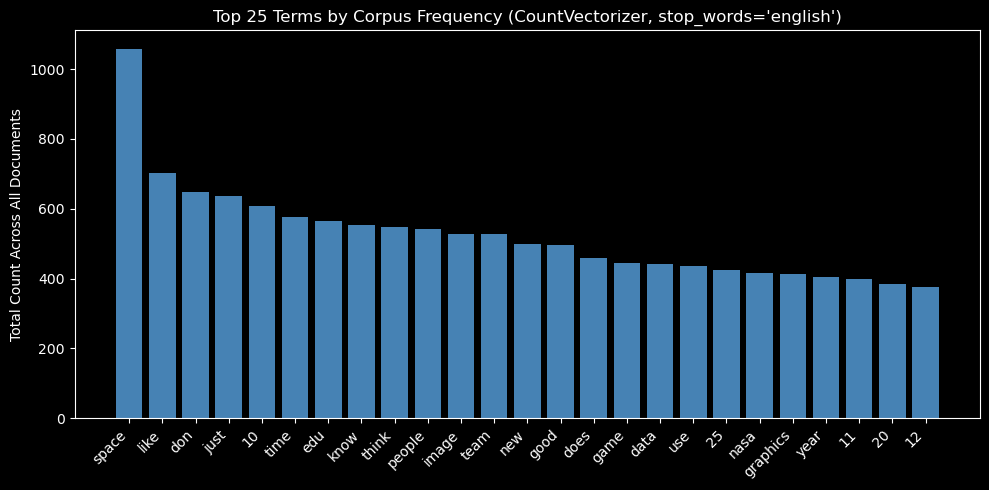

In [6]:
cv_vis = CountVectorizer(max_features=5000, stop_words='english')
X_vis  = cv_vis.fit_transform(data.data)
terms  = cv_vis.get_feature_names_out()
freqs  = np.asarray(X_vis.sum(axis=0)).ravel()

top_n = 25
top_idx   = freqs.argsort()[::-1][:top_n]
top_terms = terms[top_idx]
top_freqs = freqs[top_idx]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(top_n), top_freqs, color='steelblue')
ax.set_xticks(range(top_n))
ax.set_xticklabels(top_terms, rotation=45, ha='right')
ax.set_ylabel('Total Count Across All Documents')
ax.set_title(f'Top {top_n} Terms by Corpus Frequency (CountVectorizer, stop_words=\'english\')')
plt.tight_layout()
plt.show()

## 4. TF-IDF — Term Frequency × Inverse Document Frequency

**The problem with raw counts:** Words like *write* or *use* appear often in many documents but tell us nothing specific about a newsgroup.

**TF-IDF** downweights terms that appear in many documents and upweights terms that are distinctive to a few:

$$
\text{TF-IDF}(t, d) =
\underbrace{\text{tf}(t,d)}_{\text{count in doc}} \cdot \hspace{5pt}
\underbrace{\log\Bigg(\frac{N+1}{\text{df}(t)+1} + 1\Bigg)}_{\text{rarity across corpus}}
$$

Where:
- $\text{tf}(t,d)$ = count of term $t$ in document $d$
- $N$ = total documents
- $\text{df}(t)$ = number of documents containing $t$

In [7]:
tfidf = TfidfVectorizer(
    norm=None, # default: l2 (unit length)
    lowercase=True,
    strip_accents='unicode',
    token_pattern=r"\b[\w\-']+\b",
    stop_words='english',
    min_df=5,      # must appear in at least 5 documents
    max_df=0.75,   # ignore terms appearing in more than 95% of documents
    max_features=5000,
)
X_tfidf = tfidf.fit_transform(data.data)
tfidf_terms = tfidf.get_feature_names_out()

df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=tfidf_terms)
df_tfidf

,0,0-0,00,000,01,02,03,04,05,06,07,08,09,1,1--3,1-0,1-1,1-2,1-3,10,100,1000,101,102,1024x768,103,1030,104,105,106,107,108,109,11,110,111,112,113,114,115,116,117,118,119,12,120,1200,121,122,123,...,writing,writings,written,wrong,wrote,wuarchive,wustl,x,x-ray,x-windows,x11,x11r4,xv,y,ya,yake,yale,yawney,ye,yeah,year,year's,years,yee,yellow,yep,yes,yesterday,york,you'd,you'll,you're,you've,young,youth,ysebaert,yushkevich,yzerman,z,zalapski,zelepukin,zero,zeus,zhamnov,zhitnik,zip,zombo,zone,zoo,zubov
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,15.035953,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.596104,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,3.46061,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2149,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2150,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.922973,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.39888,0.0,0.0,0.0,0.0,5.967496,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,

In [8]:
df_tfidf.max().sort_values(ascending=False).head(20)

0         3907.030191
jpeg      1196.651186
2          910.142882
1          906.121743
25         842.173249
55         755.422464
_          604.949068
4          600.841426
pts        532.591205
14         519.176794
7          516.527158
pt         494.958328
image      482.590278
3          474.465634
6          471.187270
la         461.102561
ra         453.482500
8          440.600622
5          432.285265
launch     428.842317
dtype: float64

# CountVectorization and TFIDF Compared

In [9]:
vectorizer = CountVectorizer(
    lowercase=True,
    strip_accents='unicode',
    token_pattern=r"\b[\w\-']+\b",
    stop_words='english',
    min_df=5,
    max_df=0.75,
    max_features=5000,
)
X = vectorizer.fit_transform(data.data)
terms = vectorizer.get_feature_names_out()

df_counts = pd.DataFrame(X.toarray(), columns=terms)

In [10]:
N = 50

cv_top    = df_counts.mean().sort_values(ascending=False).head(N).reset_index()
tfidf_top = df_tfidf.mean().sort_values(ascending=False).head(N).reset_index()

cv_top.columns    = ['cv_term',    'cv_mean']
tfidf_top.columns = ['tfidf_term', 'tfidf_mean']

cv_top['cv_max']       = df_counts[cv_top['cv_term']].max().values
tfidf_top['tfidf_max'] = df_tfidf[tfidf_top['tfidf_term']].max().values

comparison = pd.concat([cv_top, tfidf_top], axis=1)
comparison

,cv_term,cv_mean,cv_max,tfidf_term,tfidf_mean,tfidf_max
0,1,1.483287,310,0,5.760886,3907.030191
1,0,1.465645,994,1,4.335608,906.121743
2,2,0.987001,309,2,2.907158,910.142882
3,3,0.675487,151,3,2.122487,474.465634
4,4,0.592386,180,4,1.977390,600.841426
5,space,0.466574,70,7,1.550817,516.527158
6,5,0.449861,128,5,1.519283,432.285265
7,7,0.411328,137,space,1.506478,226.016604
8,6,0.410399,132,6,1.464961,471.187270
9,8,0.331012,118,8,1.235967,440.600622


## Summary — CountVec vs TF-IDF

| | CountVectorizer | TfidfVectorizer |
|---|---|---|
| Values | Integer counts | Float weights |
| Common words | Rewarded (high count) | Penalized (IDF downweight) |
| Works with | Multinomial Naive Bayes | Logistic Regression, SVM |
| Best for | When raw frequency matters | Most text classification tasks |

**Next →** Notebook 3 builds classification pipelines using these feature matrices.